# Experiment 8: K-Nearest Neighbors (KNN)

## Objective
Implement K-Nearest Neighbors for binary classification.

## Problem
Use the Student Performance dataset from earlier experiments to predict:

- `pass_fail = 0` → Fail
- `pass_fail = 1` → Pass

## Requirements
Python, Pandas, NumPy, Matplotlib, Seaborn, scikit-learn, Jupyter/Google Colab, and `student_performance.csv`.

## Learning Outcomes
Students will learn to:

1. Explain instance-based learning and nearest neighbors.
2. Calculate and interpret common distance measures.
3. Standardize features without data leakage.
4. Train and evaluate a KNN classifier.
5. Understand how `k`, distance metric and voting weights affect predictions.
6. Inspect the nearest neighbors of a new record.
7. Visualize a two-feature KNN decision boundary.

## 1. KNN Theory

KNN is a supervised, non-parametric, instance-based algorithm. It stores training records and classifies a new record using its nearest training neighbors.

### Steps

1. Select the number of neighbors, \(k\).
2. Calculate the distance from the new record to training records.
3. Select the \(k\) closest records.
4. Use majority voting to predict the class.

### Euclidean Distance

For two records \(x\) and \(z\) with \(m\) features:
\[
d(x,z)=\sqrt{\sum_{j=1}^{m}(x_j-z_j)^2}
\]

### Important Choices

- Small `k`: flexible, sensitive to noise and possibly overfitting.
- Large `k`: smoother, possibly underfitting.
- `weights="uniform"`: each neighbor has equal influence.
- `weights="distance"`: closer neighbors have greater influence.
- `p=1`: Manhattan distance.
- `p=2`: Euclidean distance.

KNN is highly sensitive to scale because its decisions depend on distance.

## 2. Import Required Libraries

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, GroupShuffleSplit,
    StratifiedKFold, GroupKFold, cross_val_score
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Load the Student Performance Dataset

In [2]:
DATA_PATH = Path("/kaggle/input/datasets/tahreemrashid/student-performance-dataset/student_performance.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "student_performance.csv was not found. Place it beside this notebook "
        "or change DATA_PATH to its location."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())
df.info()

Dataset shape: (1000, 15)


,student_id,name,gender,age,class,teacher_id,subject,test1_score,test2_score,final_exam_score,final_grade_letter,attendance_percentage,study_hours_per_week,assignments_submitted,pass_fail
0,1,Carson Rivera,Female,14,9th,105,Math,23.5,40.5,50.5,F,70.2,3.1,56.7,0
1,2,Ashley Walters,Male,15,10th,107,Computer,77.7,80.6,82.3,B,85.3,6.9,81.0,1
2,3,Linda Robinson,Male,15,10th,103,English,75.0,73.4,64.5,C,83.1,4.3,66.3,1
3,4,Brandon James,Female,17,11th,117,Computer,46.7,53.1,51.2,F,74.1,0.4,44.9,0
4,5,Helen Grant,Female,16,10th,112,Science,38.0,57.3,47.6,F,73.8,1.4,49.9,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             1000 non-null   int64  
 1   name                   1000 non-null   object 
 2   gender                 1000 non-null   object 
 3   age                    1000 non-null   int64  
 4   class                  1000 non-null   object 
 5   teacher_id             1000 non-null   int64  
 6   subject                1000 non-null   object 
 7   test1_score            1000 non-null   float64
 8   test2_score            1000 non-null   float64
 9   final_exam_score       1000 non-null   float64
 10  final_grade_letter     1000 non-null   object 
 11  attendance_percentage  1000 non-null   float64
 12  study_hours_per_week   1000 non-null   float64
 13  assignments_submitted  1000 non-null   float64
 14  pass_fail              1000 non-null   int64  
dtypes: fl

## 4. Select Features and Target

The model uses five measurements expected to be available before the final result:

- `test1_score`
- `test2_score`
- `attendance_percentage`
- `study_hours_per_week`
- `assignments_submitted`

Final-exam score and final grade are excluded to avoid target leakage. Names and IDs are not predictors.

In [3]:
FEATURES = [
    "test1_score",
    "test2_score",
    "attendance_percentage",
    "study_hours_per_week",
    "assignments_submitted"
]
TARGET = "pass_fail"

missing_columns = sorted(set(FEATURES + [TARGET]) - set(df.columns))
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

data = df.drop_duplicates().copy()
print("Exact duplicate rows removed:", len(df) - len(data))

numeric_target = pd.to_numeric(data[TARGET], errors="coerce")
invalid_target = data[TARGET].notna() & (
    numeric_target.isna() | ~numeric_target.isin([0, 1])
)
if invalid_target.any():
    raise ValueError("pass_fail must contain only 0, 1, or missing values.")

print("Rows with missing target removed:", numeric_target.isna().sum())
data[TARGET] = numeric_target
data = data.dropna(subset=[TARGET]).copy()
data[TARGET] = data[TARGET].astype(int)

data[FEATURES] = data[FEATURES].apply(pd.to_numeric, errors="coerce")
data[FEATURES] = data[FEATURES].replace([np.inf, -np.inf], np.nan)

if set(data[TARGET].unique()) != {0, 1}:
    raise ValueError("Both Fail and Pass records are required.")

display(data[FEATURES].isna().sum().to_frame("Missing Values"))
display(data[FEATURES].describe().round(2))

Exact duplicate rows removed: 0
Rows with missing target removed: 0


,Missing Values
test1_score,0
test2_score,0
attendance_percentage,0
study_hours_per_week,0
assignments_submitted,0


,test1_score,test2_score,attendance_percentage,study_hours_per_week,assignments_submitted
count,1000.00,1000.00,1000.00,1000.00,1000.00
mean,63.94,66.13,82.14,4.26,68.98
std,14.76,14.95,6.90,2.29,14.09
min,17.10,24.40,63.90,0.00,22.80
25%,53.80,56.38,77.20,2.60,59.28
50%,64.00,65.70,82.10,4.10,68.50
75%,73.90,76.93,86.80,5.82,79.10
max,100.00,100.00,100.00,12.00,100.00


## 5. Examine Class Balance

,Class,Count,Percentage
0,Fail,170,17.0
1,Pass,830,83.0


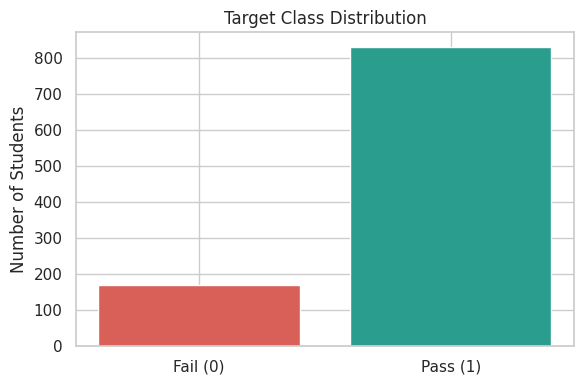

In [4]:
class_counts = data[TARGET].value_counts().reindex([0, 1], fill_value=0)

display(pd.DataFrame({
    "Class": ["Fail", "Pass"],
    "Count": class_counts.to_numpy(),
    "Percentage": 100 * class_counts.to_numpy() / len(data)
}).round(2))

plt.figure(figsize=(6, 4))
plt.bar(["Fail (0)", "Pass (1)"], class_counts,
        color=["#d95f59", "#2a9d8f"])
plt.title("Target Class Distribution")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

## 6. Split the Data

Use an 80:20 split. If a student has repeated records, a grouped split keeps that student entirely in training or testing. Otherwise, stratification preserves class proportions.

Imputation and standardization will be learned only from training records.

In [5]:
X = data[FEATURES]
y = data[TARGET]

repeated_students = (
    "student_id" in data.columns and data["student_id"].duplicated().any()
)

if repeated_students:
    if data["student_id"].isna().any():
        raise ValueError("Resolve missing student IDs before grouped splitting.")

    splitter = GroupShuffleSplit(
        n_splits=1, test_size=0.20, random_state=RANDOM_STATE
    )
    train_idx, test_idx = next(
        splitter.split(X, y, groups=data["student_id"])
    )
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    train_groups = data.iloc[train_idx]["student_id"]

    assert set(data.iloc[train_idx]["student_id"]).isdisjoint(
        set(data.iloc[test_idx]["student_id"])
    )
    print("Student-grouped split used.")
else:
    if y.value_counts().min() < 2:
        raise ValueError("At least two records of each class are required.")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y
    )
    train_groups = None
    print("Stratified split used.")

if y_train.nunique() != 2 or y_test.nunique() != 2:
    raise ValueError("Both classes must occur in training and testing sets.")

if X_train.isna().all().any():
    raise ValueError("A feature is entirely missing in training data.")

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))
display(pd.DataFrame({
    "Training": y_train.value_counts(),
    "Testing": y_test.value_counts()
}).rename(index={0: "Fail", 1: "Pass"}))

Stratified split used.
Training samples: 800
Testing samples : 200


,Training,Testing
pass_fail,,
Pass,664,166
Fail,136,34


## 7. Why Standardization Matters

Suppose attendance ranges from 0–100 while study hours range from 0–25. Without scaling, the larger numerical range may dominate the distance calculation.

The pipeline:

1. Replaces missing values using training medians.
2. Standardizes each feature using training mean and standard deviation.
3. Applies KNN with \(k=5\), Euclidean distance and uniform voting.

In [6]:
knn_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", KNeighborsClassifier(
        n_neighbors=5,
        weights="uniform",
        metric="minkowski",
        p=2
    ))
])

knn_model.fit(X_train, y_train)

print("KNN trained successfully.")
print("k =", knn_model.named_steps["classifier"].n_neighbors)
print("Distance: Euclidean (Minkowski with p=2)")

KNN trained successfully.
k = 5
Distance: Euclidean (Minkowski with p=2)


## 8. Generate Predictions and Probabilities

In [7]:
y_pred = knn_model.predict(X_test)
pass_index = list(knn_model.classes_).index(1)
pass_probability = knn_model.predict_proba(X_test)[:, pass_index]

prediction_table = X_test.copy()
prediction_table["Actual"] = y_test.map({0: "Fail", 1: "Pass"})
prediction_table["P(Pass)"] = pass_probability
prediction_table["Predicted"] = pd.Series(
    y_pred, index=X_test.index
).map({0: "Fail", 1: "Pass"})
prediction_table["Correct"] = y_test.to_numpy() == y_pred

display(prediction_table.head(15).round(3))

,test1_score,test2_score,attendance_percentage,study_hours_per_week,assignments_submitted,Actual,P(Pass),Predicted,Correct
438,62.3,56.1,64.5,3.1,35.3,Fail,0.2,Fail,True
875,43.6,42.5,71.7,0.0,52.4,Fail,0.0,Fail,True
154,62.0,73.1,90.6,5.0,66.3,Pass,1.0,Pass,True
664,57.4,59.0,80.1,3.9,66.9,Pass,1.0,Pass,True
984,45.1,44.4,77.2,2.7,68.6,Fail,0.4,Fail,True
476,70.4,86.0,93.8,5.5,88.1,Pass,1.0,Pass,True
406,60.3,62.2,78.7,1.5,53.3,Pass,1.0,Pass,True
912,52.4,69.5,75.4,2.7,52.2,Pass,1.0,Pass,True
12,56.8,61.4,79.4,3.3,58.5,Pass,1.0,Pass,True
854,56.0,47.9,83.8,1.9,67.4,Pass,1.0,Pass,True


## 9. Evaluate Against a Majority Baseline

Accuracy alone may be misleading on imbalanced data. Therefore, precision, recall, F1-score and ROC-AUC are also reported.

In [8]:
baseline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", DummyClassifier(strategy="most_frequent"))
])
baseline.fit(X_train, y_train)

def evaluate(name, model):
    predicted = model.predict(X_test)
    probabilities = model.predict_proba(X_test)
    positive_index = list(model.classes_).index(1)
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, predicted),
        "Precision (Pass)": precision_score(
            y_test, predicted, zero_division=0
        ),
        "Recall (Pass)": recall_score(
            y_test, predicted, zero_division=0
        ),
        "F1 (Pass)": f1_score(
            y_test, predicted, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test, probabilities[:, positive_index]
        )
    }

comparison = pd.DataFrame([
    evaluate("Majority Baseline", baseline),
    evaluate("KNN (k=5)", knn_model)
]).set_index("Model")

display(comparison.round(4))

print(classification_report(
    y_test,
    y_pred,
    labels=[0, 1],
    target_names=["Fail", "Pass"],
    zero_division=0
))

,Accuracy,Precision (Pass),Recall (Pass),F1 (Pass),ROC-AUC
Model,,,,,
Majority Baseline,0.830,0.8300,1.0000,0.9071,0.5000
KNN (k=5),0.955,0.9645,0.9819,0.9731,0.9903


              precision    recall  f1-score   support

        Fail       0.90      0.82      0.86        34
        Pass       0.96      0.98      0.97       166

    accuracy                           0.95       200
   macro avg       0.93      0.90      0.92       200
weighted avg       0.95      0.95      0.95       200



## 10. Confusion Matrix

True Negatives : 28
False Positives: 6
False Negatives: 3
True Positives : 163


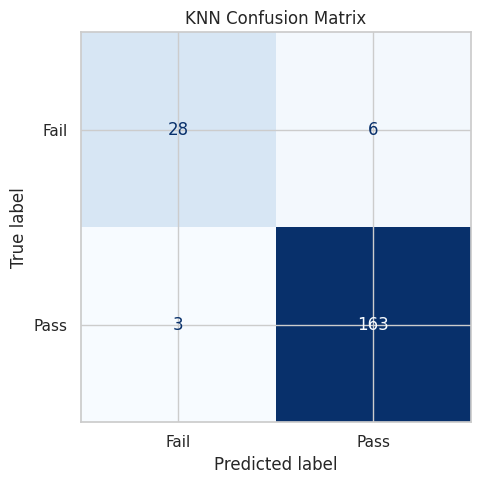

In [9]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

print(f"True Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fail", "Pass"]
).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("KNN Confusion Matrix")
plt.tight_layout()
plt.show()

## 11. ROC Curve

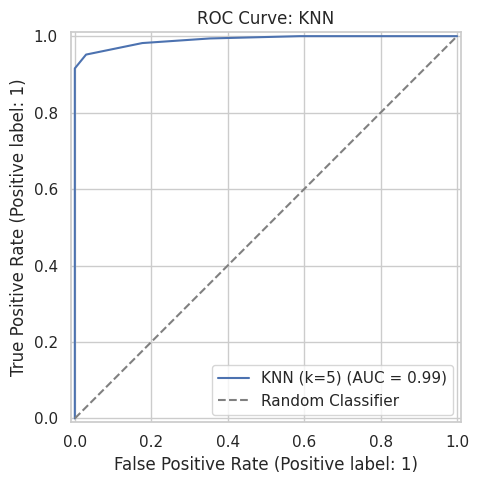

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(
    y_test,
    pass_probability,
    name="KNN (k=5)",
    ax=ax
)
ax.plot([0, 1], [0, 1], "--", color="gray", label="Random Classifier")
ax.set_title("ROC Curve: KNN")
ax.legend()
plt.tight_layout()
plt.show()

## 12. Select k Using Training-Only Cross-Validation

The final test set must not be used to choose \(k\). This cell compares odd values of \(k\) using only training data.

- Ordinary data: stratified 5-fold cross-validation.
- Repeated students: group-aware cross-validation so the same student does not cross folds.

The number of folds is reduced automatically when the training data is small.

,k,Mean CV F1,Std CV F1
0,1,0.9556,0.0085
1,3,0.9647,0.0098
2,5,0.9641,0.0071
3,7,0.9709,0.0042
4,9,0.9693,0.0042
5,11,0.9739,0.0046
6,15,0.9717,0.0064


Best k by training-only mean CV F1: 11


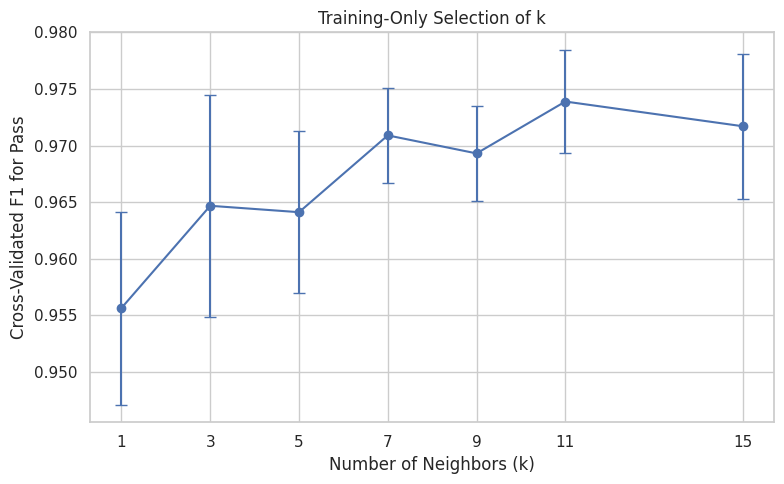

In [11]:
candidate_k = [1, 3, 5, 7, 9, 11, 15]
validation_rows = []

if repeated_students:
    n_splits = min(5, train_groups.nunique())
    if n_splits < 2:
        raise ValueError("At least two student groups are required for cross-validation.")
    cv = GroupKFold(n_splits=n_splits)
    cv_groups = train_groups
else:
    n_splits = min(5, int(y_train.value_counts().min()))
    if n_splits < 2:
        raise ValueError("At least two examples per class are required.")
    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=RANDOM_STATE
    )
    cv_groups = None

for k in candidate_k:
    if k >= len(X_train):
        continue

    candidate = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("classifier", KNeighborsClassifier(
            n_neighbors=k,
            weights="uniform",
            p=2
        ))
    ])

    scores = cross_val_score(
        candidate,
        X_train,
        y_train,
        cv=cv,
        groups=cv_groups,
        scoring="f1",
        error_score="raise"
    )

    validation_rows.append({
        "k": k,
        "Mean CV F1": scores.mean(),
        "Std CV F1": scores.std()
    })

k_results = pd.DataFrame(validation_rows)
display(k_results.round(4))

best_k = int(k_results.loc[k_results["Mean CV F1"].idxmax(), "k"])
print("Best k by training-only mean CV F1:", best_k)

plt.figure(figsize=(8, 5))
plt.errorbar(
    k_results["k"],
    k_results["Mean CV F1"],
    yerr=k_results["Std CV F1"],
    marker="o",
    capsize=4
)
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Cross-Validated F1 for Pass")
plt.title("Training-Only Selection of k")
plt.xticks(k_results["k"])
plt.tight_layout()
plt.show()

## 13. Fit the Selected-k Model and Evaluate Once on Test Data

This model uses the \(k\) selected by training-only cross-validation. The untouched test set is now used for final evaluation.

In [12]:
selected_knn = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", KNeighborsClassifier(
        n_neighbors=best_k,
        weights="uniform",
        p=2
    ))
])

selected_knn.fit(X_train, y_train)
selected_pred = selected_knn.predict(X_test)
selected_prob = selected_knn.predict_proba(X_test)[
    :, list(selected_knn.classes_).index(1)
]

selected_metrics = pd.DataFrame([{
    "Selected k": best_k,
    "Accuracy": accuracy_score(y_test, selected_pred),
    "Precision (Pass)": precision_score(
        y_test, selected_pred, zero_division=0
    ),
    "Recall (Pass)": recall_score(
        y_test, selected_pred, zero_division=0
    ),
    "F1 (Pass)": f1_score(
        y_test, selected_pred, zero_division=0
    ),
    "ROC-AUC": roc_auc_score(y_test, selected_prob)
}])

display(selected_metrics.round(4))

,Selected k,Accuracy,Precision (Pass),Recall (Pass),F1 (Pass),ROC-AUC
0,11,0.96,0.9647,0.988,0.9762,0.9914


## 14. Compare Distance Metrics and Voting Weights

This table is an exploratory comparison on the fixed test set. Do not select a production configuration by repeatedly examining test results. Include these choices inside training-only cross-validation when tuning.

In [13]:
configuration_rows = []

for p_value, distance_name in [(1, "Manhattan"), (2, "Euclidean")]:
    for weight_method in ["uniform", "distance"]:
        model = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("classifier", KNeighborsClassifier(
                n_neighbors=best_k,
                weights=weight_method,
                p=p_value
            ))
        ])
        model.fit(X_train, y_train)
        predicted = model.predict(X_test)

        configuration_rows.append({
            "Distance": distance_name,
            "Weights": weight_method,
            "Accuracy": accuracy_score(y_test, predicted),
            "F1 (Pass)": f1_score(
                y_test, predicted, zero_division=0
            )
        })

display(pd.DataFrame(configuration_rows).round(4))

,Distance,Weights,Accuracy,F1 (Pass)
0,Manhattan,uniform,0.965,0.9790
1,Manhattan,distance,0.965,0.9790
2,Euclidean,uniform,0.960,0.9762
3,Euclidean,distance,0.955,0.9733


## 15. Visualize a Two-Feature Decision Boundary

A separate KNN using only Test 1 and Test 2 scores is created for visualization. It is not the main five-feature model.

KNN boundaries are local and can become irregular when \(k\) is small.

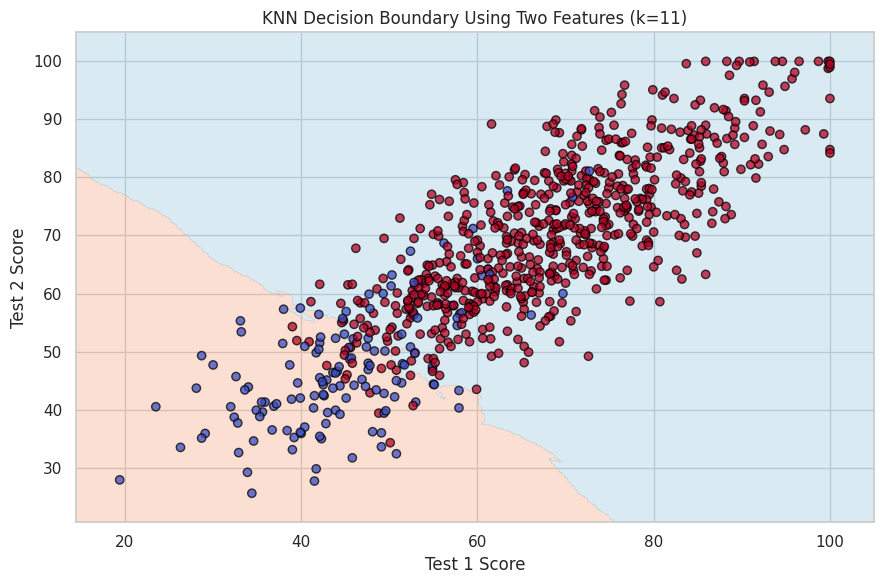

In [14]:
PLOT_FEATURES = ["test1_score", "test2_score"]

visual_knn = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", KNeighborsClassifier(
        n_neighbors=best_k,
        weights="uniform",
        p=2
    ))
])
visual_knn.fit(X_train[PLOT_FEATURES], y_train)

x_min = X_train[PLOT_FEATURES[0]].min() - 5
x_max = X_train[PLOT_FEATURES[0]].max() + 5
y_min = X_train[PLOT_FEATURES[1]].min() - 5
y_max = X_train[PLOT_FEATURES[1]].max() + 5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 250),
    np.linspace(y_min, y_max, 250)
)

grid = pd.DataFrame({
    PLOT_FEATURES[0]: xx.ravel(),
    PLOT_FEATURES[1]: yy.ravel()
})
grid_prediction = visual_knn.predict(grid).reshape(xx.shape)

plt.figure(figsize=(9, 6))
plt.contourf(
    xx, yy, grid_prediction,
    levels=[-0.5, 0.5, 1.5],
    colors=["#f4a582", "#92c5de"],
    alpha=0.35
)
plt.scatter(
    X_train[PLOT_FEATURES[0]],
    X_train[PLOT_FEATURES[1]],
    c=y_train,
    cmap="coolwarm",
    edgecolor="black",
    alpha=0.75
)
plt.xlabel("Test 1 Score")
plt.ylabel("Test 2 Score")
plt.title(f"KNN Decision Boundary Using Two Features (k={best_k})")
plt.tight_layout()
plt.show()

## 16. Predict a New Student and Inspect Nearest Neighbors

The following record is hypothetical. KNN finds its nearest training records in standardized space. Distances therefore refer to standardized units.

In [15]:
new_student = pd.DataFrame([{
    "test1_score": 65,
    "test2_score": 70,
    "attendance_percentage": 85,
    "study_hours_per_week": 12,
    "assignments_submitted": 90
}])

new_class = selected_knn.predict(new_student)[0]
new_probability = selected_knn.predict_proba(new_student)[
    0, list(selected_knn.classes_).index(1)
]

print("Predicted class:", "Pass" if new_class == 1 else "Fail")
print(f"Estimated probability of Pass: {new_probability:.2%}")

new_imputed = selected_knn.named_steps["imputer"].transform(new_student)
new_scaled = selected_knn.named_steps["scaler"].transform(new_imputed)

distances, neighbor_positions = selected_knn.named_steps[
    "classifier"
].kneighbors(new_scaled, n_neighbors=best_k)

neighbor_table = X_train.iloc[neighbor_positions[0]].copy()
neighbor_table["Class"] = y_train.iloc[
    neighbor_positions[0]
].map({0: "Fail", 1: "Pass"}).to_numpy()
neighbor_table["Standardized Distance"] = distances[0]

display(neighbor_table.round(3))

Predicted class: Pass
Estimated probability of Pass: 100.00%


,test1_score,test2_score,attendance_percentage,study_hours_per_week,assignments_submitted,Class,Standardized Distance
624,64.6,75.0,85.0,7.9,83.0,Pass,1.854
489,73.9,81.0,88.8,8.8,100.0,Pass,1.883
827,73.3,91.5,87.8,9.1,89.5,Pass,2.001
505,80.7,58.6,83.2,8.2,85.5,Pass,2.113
724,81.3,94.7,88.6,10.7,95.0,Pass,2.124
942,79.1,82.1,83.3,8.4,79.3,Pass,2.126
261,71.5,78.7,89.6,7.6,94.1,Pass,2.141
910,68.8,87.8,83.4,8.6,75.2,Pass,2.168
804,72.2,70.3,86.8,8.6,68.6,Pass,2.169
514,79.2,81.8,87.7,8.5,77.1,Pass,2.173


## 17. Conclusion

A KNN classifier was implemented to predict whether a student will Pass or Fail. Missing values and standardization were handled inside a leakage-safe pipeline. The model was evaluated using accuracy, precision, recall, F1-score, ROC-AUC and a confusion matrix. The value of \(k\) was selected using training-only cross-validation.

### Observation Template

“Using ___ training and ___ testing records, training-only cross-validation selected \(k=\)___. The selected KNN obtained accuracy ___, F1-score ___ and ROC-AUC ___. Compared with the majority baseline, ___. Its main limitation was ___.”

### Limitations

- Prediction can be slow because distances to stored training records are calculated.
- KNN is sensitive to scaling, irrelevant features, outliers and the choice of \(k\).
- Distance becomes less informative in very high-dimensional spaces.
- Class imbalance may dominate neighbor voting.
- Probability values are based on local neighbor proportions and are not guarantees.

## Viva Questions with Short Answers

1. **What is KNN?** A supervised method that predicts from the classes of nearby training records.
2. **Why is KNN called a lazy learner?** It stores training data and defers most computation until prediction.
3. **What does k represent?** The number of nearest neighbors used.
4. **What happens when k is very small?** The model becomes sensitive to noise and may overfit.
5. **What happens when k is very large?** The boundary becomes smoother and may underfit.
6. **Why use an odd k in binary classification?** It reduces the chance of a tied vote.
7. **Why standardize data?** Features with larger ranges would otherwise dominate distance.
8. **Euclidean versus Manhattan distance?** Euclidean measures straight-line distance; Manhattan sums absolute coordinate differences.
9. **What is distance-weighted voting?** Closer neighbors receive greater influence.
10. **Does KNN train model coefficients?** No; it stores training examples and uses distances at prediction time.
11. **Can KNN handle multiclass classification?** Yes.
12. **Why may KNN be slow at prediction?** It calculates distances to many stored records.
13. **What is the curse of dimensionality?** Distances become less discriminative as dimensions increase.
14. **Why select k using cross-validation?** To estimate generalization using training data without tuning on the test set.
15. **Why use group-aware cross-validation for repeated students?** It prevents the same student appearing across training and validation folds.
16. **Does a high Pass probability guarantee passing?** No; it is only a model estimate.
17. **Why exclude final scores?** They may leak the result and be unavailable when making the prediction.

## Practice Exercises

1. Compare \(k=1,3,5,7,9\).
2. Compare Euclidean and Manhattan distances through training-only cross-validation.
3. Compare uniform and distance-weighted voting.
4. Try `class_weight` alternatives indirectly through resampling and inspect Fail recall.
5. Compare Logistic Regression, Decision Tree, Random Forest, SVM and KNN using identical rows, split and metrics.